## Intel Image classification -  Using CNN
#### Total 6 categories : 'mountain', 'street', 'glacier', 'buildings', 'sea', 'forest'
#### We're going to use tensorflow keras library - CPU version

In [ ]:
!pip install tensorflow

  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/ed/b6/62345568cd07de5d9254fcf64d7e44aacbb6abde11ea953b3cb320e58d19/tensorflow-2.17.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for tensorflow-intel==2.17.0 from https://files.pythonhosted.org/packages/66/03/5c447feceb72f5a38ac2aa79d306fa5b5772f982c2b480c1329c7e382900/tensorflow_intel-2.17.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/a2/ad/e0d3c824784ff121c03cc031f944bc7e139a8f1870ffd2845cc2dd76f6c4/absl_py-2.1.0-py3-none-any.whl.metadata
  Obtaining dependency information for astunparse>=1.6.0 from https://files.pythonhosted.org/packages/2b/03/13dde6512ad7b4557eb792fbcf0c653af6076b81e5941d36ec61f7ce6028/astunparse-1.6.3-py2.py3-none-any.whl.metadata
  Obtaining dependency information for flatbuffers>=24.3.25 from https://files.pythonhosted.org/packages/41/f0/7e988a019bc54b2db

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
!tar -xzf cifar-10-python.tar.gz

In [ ]:
import numpy as np
import os
from sklearn.metrics import confusion_matrix
import seaborn as sn; sn.set(font_scale=1.4)
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tqdm import tqdm

In [ ]:
ls

 Volume in drive C has no label.
 Volume Serial Number is A2C0-C792

 Directory of C:\Users\32573\Desktop\Sheel-Work\Learn to Code

08-02-2024  14:42    <DIR>          .
08-02-2024  14:42    <DIR>          ..
01-02-2024  15:08    <DIR>          .ipynb_checkpoints
25-01-2024  11:05    <DIR>          Data
25-01-2024  14:51             3,606 Dinosaur Game.ipynb
03-02-2024  12:12           172,080 Image_Classificaiton_ANN.ipynb
08-02-2024  14:42         2,636,842 Image_Classification_CNN.ipynb
25-01-2024  16:34        63,878,320 intel_image_cnn.h5
25-01-2024  14:57    <DIR>          intel_image_cnn_vgg16
29-01-2024  16:17         3,301,120 intel_image_cnn_vgg16.h5
01-02-2024  15:29             1,383 numpy.ipynb
01-02-2024  15:07         3,158,527 Object Detection (YOLO).ipynb
03-02-2024  11:46             2,785 Untitled.ipynb
01-02-2024  15:17    <DIR>          Yolo
               8 File(s)     73,154,663 bytes
               6 Dir(s)  308,476,514,304 bytes free


In [ ]:
class_names = ['mountain', 'street', 'glacier', 'buildings', 'sea', 'forest']
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

nb_classes = len(class_names)

IMAGE_SIZE = (150, 150)

## Load the data

In [ ]:
train_data_path = "Data/Intel classifier challenge/seg_train/seg_train"
test_data_path = "Data/Intel classifier challenge/seg_test/seg_test"

folder_name = [i for i in os.listdir(train_data_path)]

train_images =[]
train_labels = []
test_images = []
test_labels = []

for folder  in folder_name:
    for item in tqdm(os.listdir(os.path.join(train_data_path,folder))):
        train_image= cv2.imread(os.path.join(os.path.join(train_data_path,folder),item))
        train_image = cv2.cvtColor(train_image, cv2.COLOR_BGR2RGB)
        train_image = cv2.resize(train_image, IMAGE_SIZE)
        train_images.append(train_image)
        train_labels.append(folder_name.index(folder))

    for item in tqdm(os.listdir(os.path.join(test_data_path,folder))):
        test_image = cv2.imread(os.path.join(os.path.join(test_data_path,folder),item))
        test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
        test_image = cv2.resize(test_image, IMAGE_SIZE)
        test_images.append(test_image)
        test_labels.append(folder_name.index(folder))

train_images = np.array(train_images, dtype = 'float32')
train_labels = np.array(train_labels, dtype = 'int32')
test_images = np.array(test_images, dtype = 'float32')
test_labels = np.array(test_labels, dtype = 'int32')

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Data/Intel classifier challenge/seg_train/seg_train'

### Shuffle the images in training and testing samples

In [ ]:
train_images, train_labels = shuffle(train_images, train_labels, random_state=19)

In [ ]:
print('Number of training samples : ',len(train_images))
print('Number of testing samples : ',len(test_images))
print('Pixel size of each image : ',train_images[0].shape)

Number of training samples :  14034
Number of testing samples :  3000
Pixel size of each image :  (150, 150, 3)


### Scale the data

In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

### Show the examples images

In [ ]:
def display_random_image(class_names, images, labels):

    index = np.random.randint(images.shape[0])
    plt.figure()
    plt.imshow(images[index])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('Image #{} : '.format(index) + class_names[labels[index]])
    plt.show()

In [ ]:
def display_examples(class_names, images, labels):

    fig = plt.figure(figsize=(10,10))
    for i in range(16):
        plt.subplot(4,4,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[labels[i]])
    plt.show()

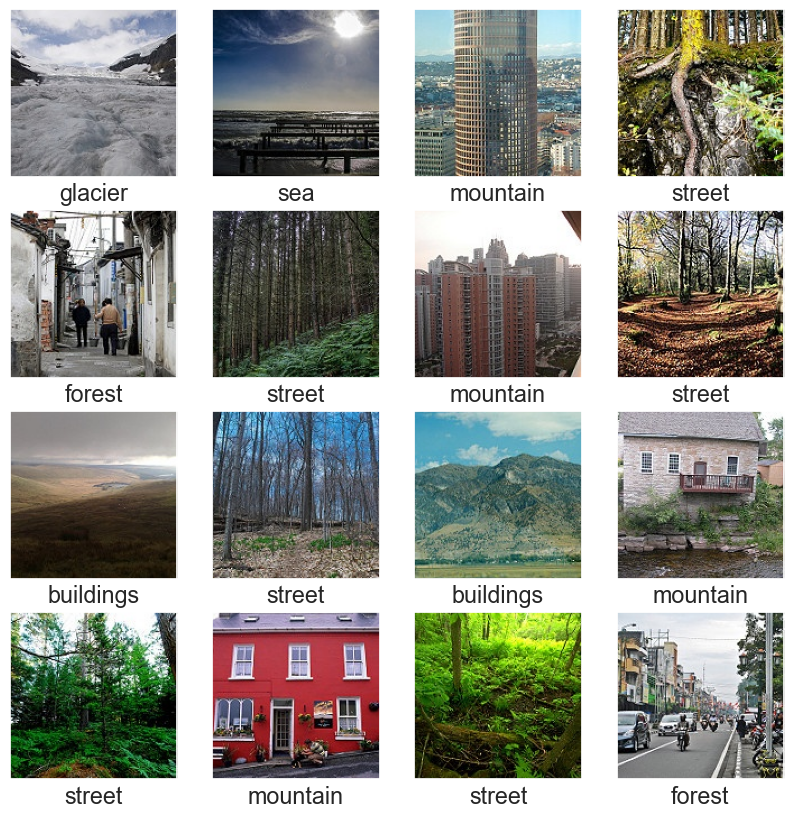

In [ ]:
display_examples(class_names, train_images, train_labels)

## Build the model

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(128, (3, 3), activation = 'relu', input_shape = (150, 150, 3)),  #1st hidden convolution layer : Input layer
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(.2, input_shape=(2,)),

    tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu'), #2nd hidden convolution layer
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(.2, input_shape=(2,)),

    tf.keras.layers.Flatten(), #Flatten out the convoluted patterns to connect with fully connected neural network
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #Fully connected dense layer
    tf.keras.layers.Dense(6, activation=tf.nn.softmax) #Output layer - 6: no. of classes
])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 128)     3584      
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 128)       0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 74, 74, 128)       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        73792     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 36, 36, 64)        0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 36, 36, 64)        0

### Compile the model

In [ ]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

### Train-fit the model

In [ ]:
history = model.fit(train_images, train_labels, batch_size=128, epochs=20, validation_split = 0.3)

Epoch 1/20


77/77 [==============================] - 209s 3s/step - loss: 50.8774 - accuracy: 0.2010 - val_loss: 1.7308 - val_accuracy: 0.2871
Epoch 2/20
77/77 [==============================] - 206s 3s/step - loss: 1.6424 - accuracy: 0.3408 - val_loss: 1.7544 - val_accuracy: 0.2187
Epoch 3/20
77/77 [==============================] - 205s 3s/step - loss: 1.4940 - accuracy: 0.4043 - val_loss: 1.5098 - val_accuracy: 0.3629
Epoch 4/20
77/77 [==============================] - 206s 3s/step - loss: 1.2929 - accuracy: 0.4828 - val_loss: 1.4707 - val_accuracy: 0.3714
Epoch 5/20
77/77 [==============================] - 206s 3s/step - loss: 1.1141 - accuracy: 0.5554 - val_loss: 1.4656 - val_accuracy: 0.3854
Epoch 6/20
77/77 [==============================] - 205s 3s/step - loss: 0.9717 - accuracy: 0.6074 - val_loss: 1.6040 - val_accuracy: 0.3688
Epoch 7/20
77/77 [==============================] - 208s 3s/step - loss: 0.8852 - accuracy: 0.6389 - val_loss: 1.5339 - val_accuracy: 0.4346
Epoch 8/20

### Save and load the model

In [ ]:
model.save('intel_image_cnn.h5')

In [ ]:
model = tf.keras.models.load_model('intel_image_cnn.h5')

In [ ]:
img=cv2.imread('20057.jpg')

In [ ]:
img

array([[[174, 119,  92],
        [189, 140, 114],
        [166, 124, 101],
        ...,
        [207, 148, 109],
        [208, 149, 110],
        [208, 149, 110]],

       [[160, 113,  86],
        [227, 181, 157],
        [204, 163, 141],
        ...,
        [205, 146, 106],
        [206, 147, 107],
        [206, 147, 107]],

       [[186, 152, 128],
        [195, 161, 138],
        [213, 176, 156],
        ...,
        [205, 145, 103],
        [205, 145, 103],
        [205, 145, 103]],

       ...,

       [[224, 207, 198],
        [224, 207, 198],
        [223, 206, 197],
        ...,
        [242, 230, 224],
        [243, 233, 226],
        [245, 235, 228]],

       [[224, 206, 195],
        [224, 206, 195],
        [224, 206, 195],
        ...,
        [242, 230, 224],
        [245, 235, 228],
        [249, 239, 232]],

       [[222, 205, 192],
        [222, 205, 192],
        [223, 205, 194],
        ...,
        [241, 229, 223],
        [247, 237, 230],
        [251, 241, 234]]

In [ ]:
img2

array([[[[174, 119,  92],
         [189, 140, 114],
         [166, 124, 101],
         ...,
         [207, 148, 109],
         [208, 149, 110],
         [208, 149, 110]],

        [[160, 113,  86],
         [227, 181, 157],
         [204, 163, 141],
         ...,
         [205, 146, 106],
         [206, 147, 107],
         [206, 147, 107]],

        [[186, 152, 128],
         [195, 161, 138],
         [213, 176, 156],
         ...,
         [205, 145, 103],
         [205, 145, 103],
         [205, 145, 103]],

        ...,

        [[224, 207, 198],
         [224, 207, 198],
         [223, 206, 197],
         ...,
         [242, 230, 224],
         [243, 233, 226],
         [245, 235, 228]],

        [[224, 206, 195],
         [224, 206, 195],
         [224, 206, 195],
         ...,
         [242, 230, 224],
         [245, 235, 228],
         [249, 239, 232]],

        [[222, 205, 192],
         [222, 205, 192],
         [223, 205, 194],
         ...,
         [241, 229, 223],
        

In [ ]:
img2 = img.reshape(-1,150,150,3)

In [ ]:
model.predict(img2)

1/1 [==============================] - 0s 13ms/step


array([[1., 0., 0., 0., 0., 0.]], dtype=float32)

In [ ]:
def plot_accuracy_loss(history):

    fig = plt.figure(figsize=(10,5))

    # Plot accuracy
    plt.subplot(2,1,1)
    plt.plot(history.history['accuracy'],'bo--', label = "acc")
    plt.plot(history.history['val_accuracy'], 'ro--', label = "val_acc")
    plt.title("train_acc vs val_acc")
    plt.ylabel("accuracy")
    plt.xlabel("epochs")
    plt.legend()

    # Plot loss function
    plt.subplot(2,1,2)
    plt.plot(history.history['loss'],'bo--', label = "loss")
    plt.plot(history.history['val_loss'], 'ro--', label = "val_loss")
    plt.title("train_loss vs val_loss")
    plt.ylabel("loss")
    plt.xlabel("epochs")

    plt.legend()
    plt.show()

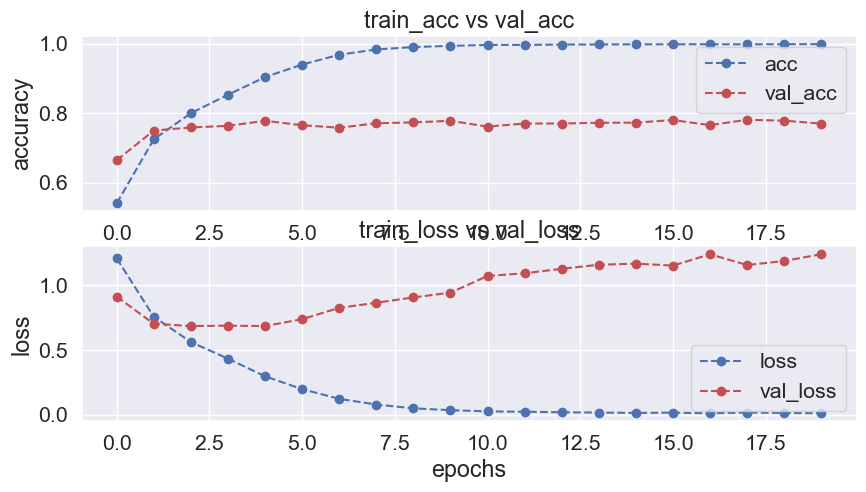

In [ ]:
plot_accuracy_loss(history)

## Evaluate the model and compute test loss

In [ ]:
test_loss = model.evaluate(test_images, test_labels)

94/94 [==============================] - 7s 71ms/step - loss: 0.9842 - accuracy: 0.7703


In [ ]:
predictions = model.predict(test_images)     # Vector of probabilities
pred_labels = np.argmax(predictions, axis = 1) # We take the highest probability

94/94 [==============================] - 7s 70ms/step


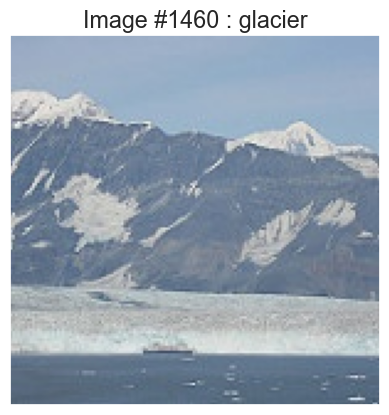

In [ ]:
display_random_image(class_names, test_images, pred_labels)

### Confusion Matrix

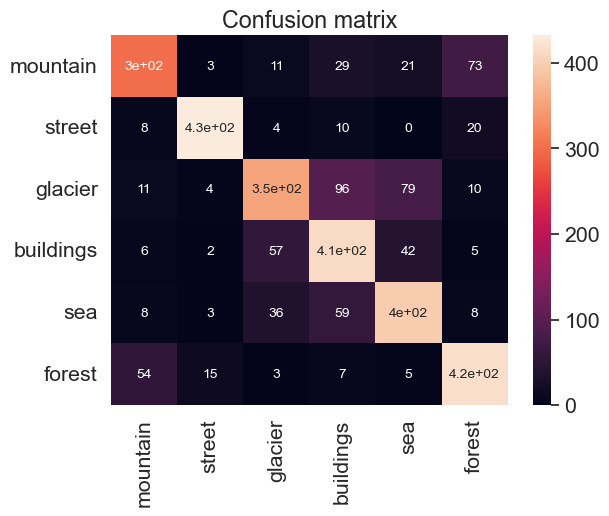

In [ ]:
CM = confusion_matrix(test_labels, pred_labels)
ax = plt.axes()
sn.heatmap(CM, annot=True,
           annot_kws={"size": 10},
           xticklabels=class_names,
           yticklabels=class_names, ax = ax)
ax.set_title('Confusion matrix')
plt.show()

## Transfer Learning
### We're going to use VGG16 ImageNet model features and further train on that

In [ ]:
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input

model = VGG16(weights='imagenet', include_top=False)

In [ ]:
train_features = model.predict(train_images)
test_features = model.predict(test_images)

94/94 [==============================] - 48s 510ms/step


### Visualize the features with PCA

In [ ]:
n_train, x, y, z = train_features.shape
n_test, x, y, z = test_features.shape
numFeatures = x * y * z

In [ ]:
from sklearn import decomposition

pca = decomposition.PCA(n_components = 2)

X = train_features.reshape((n_train, x*y*z))
pca.fit(X)

C = pca.transform(X) # Représentation des individus dans les nouveaux axe
C1 = C[:,0]
C2 = C[:,1]

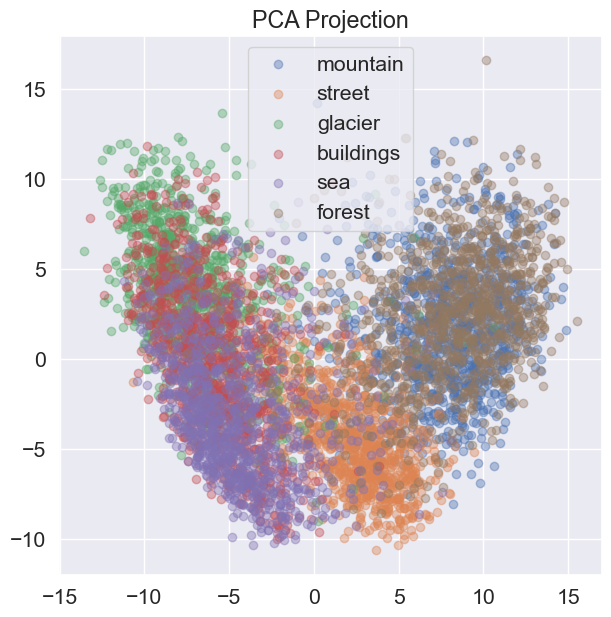

In [ ]:
plt.subplots(figsize=(7,7))

for i, class_name in enumerate(class_names):
    plt.scatter(C1[train_labels == i][:1000], C2[train_labels == i][:1000], label = class_name, alpha=0.4)
plt.legend()
plt.title("PCA Projection")
plt.show()

### Define the model for VGG Imagenet features

In [ ]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (x, y, z)),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(6, activation=tf.nn.softmax)
])

### Model compilation

In [ ]:
model2.compile(optimizer = 'RMSprop', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

### Train and fit the model

In [ ]:
history2 = model2.fit(train_features, train_labels, batch_size=64, epochs=20, validation_split = 0.2)

Epoch 1/20
176/176 [==============================] - 0s 2ms/step - loss: 0.0085 - accuracy: 0.9977 - val_loss: 0.9805 - val_accuracy: 0.8561
Epoch 2/20
176/176 [==============================] - 0s 2ms/step - loss: 0.0176 - accuracy: 0.9950 - val_loss: 0.8838 - val_accuracy: 0.8707
Epoch 3/20
176/176 [==============================] - 0s 2ms/step - loss: 0.0163 - accuracy: 0.9953 - val_loss: 0.9150 - val_accuracy: 0.8746
Epoch 4/20
176/176 [==============================] - 0s 2ms/step - loss: 0.0139 - accuracy: 0.9961 - val_loss: 0.9048 - val_accuracy: 0.8714
Epoch 5/20
176/176 [==============================] - 0s 2ms/step - loss: 0.0181 - accuracy: 0.9948 - val_loss: 0.9777 - val_accuracy: 0.8664
Epoch 6/20
176/176 [==============================] - 0s 2ms/step - loss: 0.0107 - accuracy: 0.9968 - val_loss: 0.9697 - val_accuracy: 0.8703
Epoch 7/20
176/176 [==============================] - 0s 2ms/step - loss: 0.0129 - accuracy: 0.9962 - val_loss: 1.0531 - val_accuracy: 0.8639
Epoch 

In [ ]:
model2.save('intel_image_cnn_vgg16.h5')

C:\Users\32573\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
model2 = tf.keras.models.load_model('intel_image_cnn_vgg16.h5')

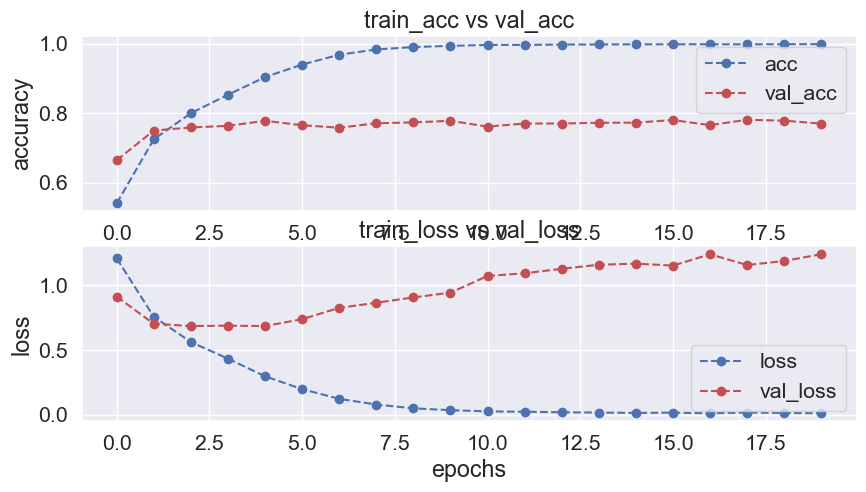

In [ ]:
plot_accuracy_loss(history)

### Test loss and accuracy computation

In [ ]:
test_loss = model2.evaluate(test_features, test_labels)

94/94 [==============================] - 0s 743us/step - loss: 0.8915 - accuracy: 0.8783


### Predict the class label for random test_images

In [ ]:
def random_predict():
    n = np.random.randint(0,3000)
    pred_class = class_names[np.argmax(model2.predict(test_features[n:n+1]))]
    print(n)
    plt.imshow(test_images[n])
    plt.title(pred_class)

1/1 [==============================] - 0s 16ms/step
951


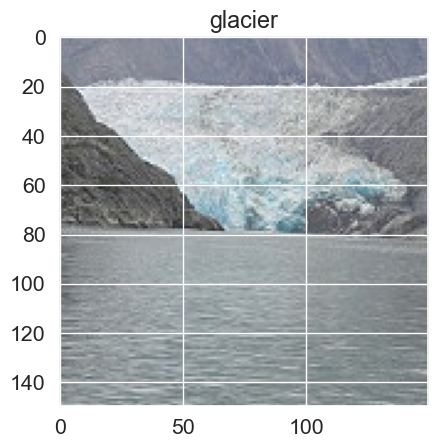

In [ ]:
random_predict()

94/94 [==============================] - 0s 734us/step


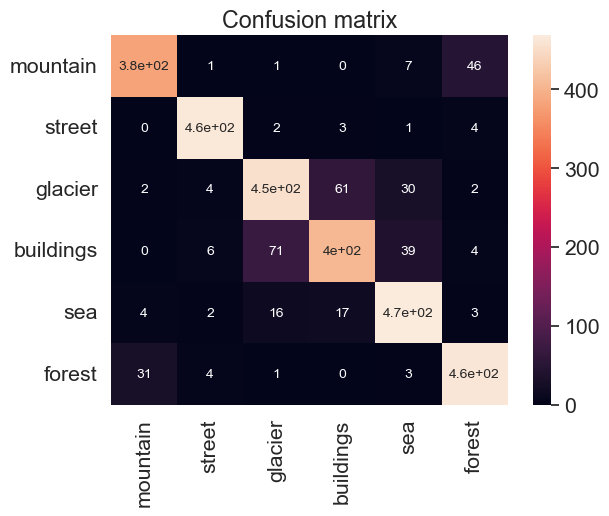

In [ ]:
predictions = model2.predict(test_features)     # Vector of probabilities
pred_labels = np.argmax(predictions, axis = 1) # We take the highest probability
CM = confusion_matrix(test_labels, pred_labels)
ax = plt.axes()
sn.heatmap(CM, annot=True,
           annot_kws={"size": 10},
           xticklabels=class_names,
           yticklabels=class_names, ax = ax)
ax.set_title('Confusion matrix')
plt.show()